# QELM vs QK

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import myQMLfunctions as myQML

In [2]:
rho_training, rho_test, expe_training_X, expe_training_Y, expe_training_Z, expe_test_X, expe_test_Y, expe_test_Z = myQML.generate_dataset_pauli(100, 1000)

In [3]:
print(rho_training.shape)
print(rho_training)
print('\n')
print(rho_training[0])

(100, 2, 2)
[[[ 0.46695249+0.j         -0.34739539-0.33306208j]
  [-0.34739539+0.33306208j  0.53304751+0.j        ]]

 [[ 0.63468421+0.j         -0.09065444-0.11812385j]
  [-0.09065444+0.11812385j  0.36531579+0.j        ]]

 [[ 0.27226881+0.j          0.02485183+0.23737573j]
  [ 0.02485183-0.23737573j  0.72773119+0.j        ]]

 [[ 0.7190262 +0.j         -0.00172432-0.08309489j]
  [-0.00172432+0.08309489j  0.2809738 +0.j        ]]

 [[ 0.47450905+0.j         -0.27073145-0.11466035j]
  [-0.27073145+0.11466035j  0.52549095+0.j        ]]

 [[ 0.54545337+0.j          0.23651014+0.40148312j]
  [ 0.23651014-0.40148312j  0.45454663+0.j        ]]

 [[ 0.47452035+0.j          0.01543098-0.34471101j]
  [ 0.01543098+0.34471101j  0.52547965+0.j        ]]

 [[ 0.55297624+0.j         -0.32408576-0.31499005j]
  [-0.32408576+0.31499005j  0.44702376+0.j        ]]

 [[ 0.68667839+0.j          0.43425906+0.00670118j]
  [ 0.43425906-0.00670118j  0.31332161+0.j        ]]

 [[ 0.43248382+0.j          0.2829

In [4]:
rho = myQML.generate_random_density_matrix(2)
print(rho)
print(np.trace(rho))

[[ 0.37335541-7.24897131e-19j -0.24796819+2.53302250e-01j]
 [-0.24796819-2.53302250e-01j  0.62664459+7.24897131e-19j]]
(1+9.62964972193618e-34j)


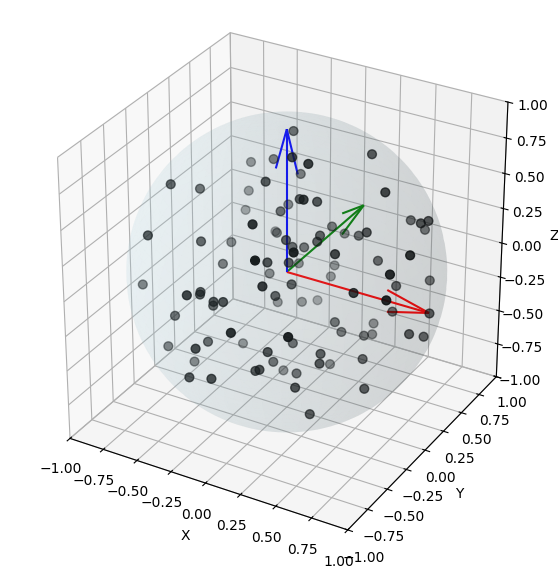

In [5]:
bloch_points_1 = [myQML.density_to_bloch(rho) for rho in rho_training]
myQML.plot_bloch_sphere(bloch_points_1)

In [ ]:
kernelmodel = myQML.QuantumKernelRegression(regularization_lambda=0)
kernelmodel.fit(rho_training, expe_training_X)
predictions = kernelmodel.predict(rho_test)
print(f"\nPredictions on test data (first 5):\n{predictions[:5]}")
print(f"Original test labels (first 5):\n{expe_test_X[:5]}")

# Calculate Mean Squared Error on training data
mse = np.mean((predictions - expe_test_X)**2)
print(f"Mean Squared Error on training data: {mse:.4f}")

predictions_training = kernelmodel.predict(rho_training)
print(f"\nPredictions on training data (first 5):\n{predictions_training[:5]}")
print(f"Original training labels (first 5):\n{expe_training_X[:5]}")